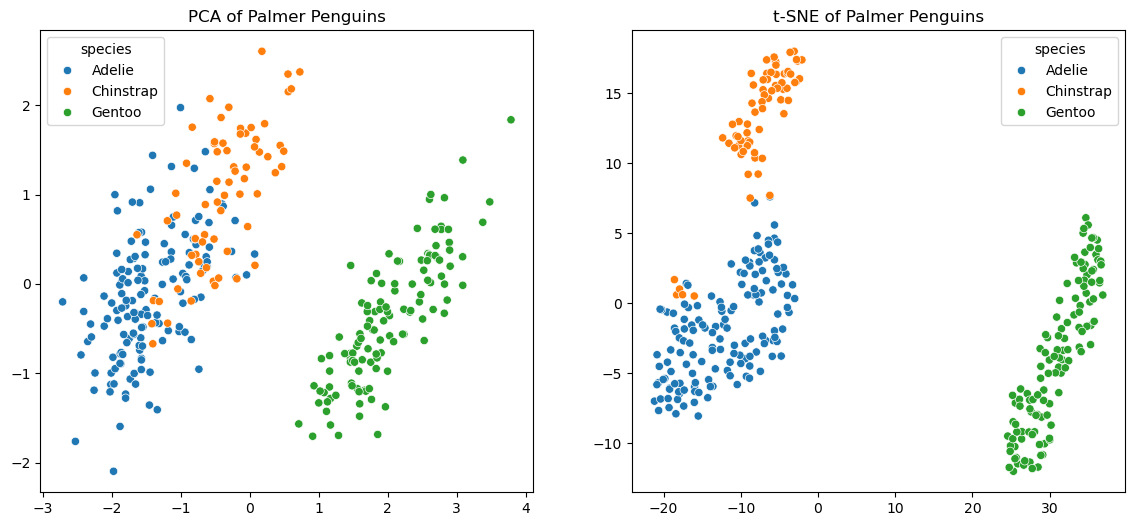

K-Means Silhouette Score: 0.446
DBSCAN 1 Silhouette Score: 0.467
DBSCAN 2 Silhouette Score: 0.467
K-Means ARI: 0.799 | NMI: 0.790


c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


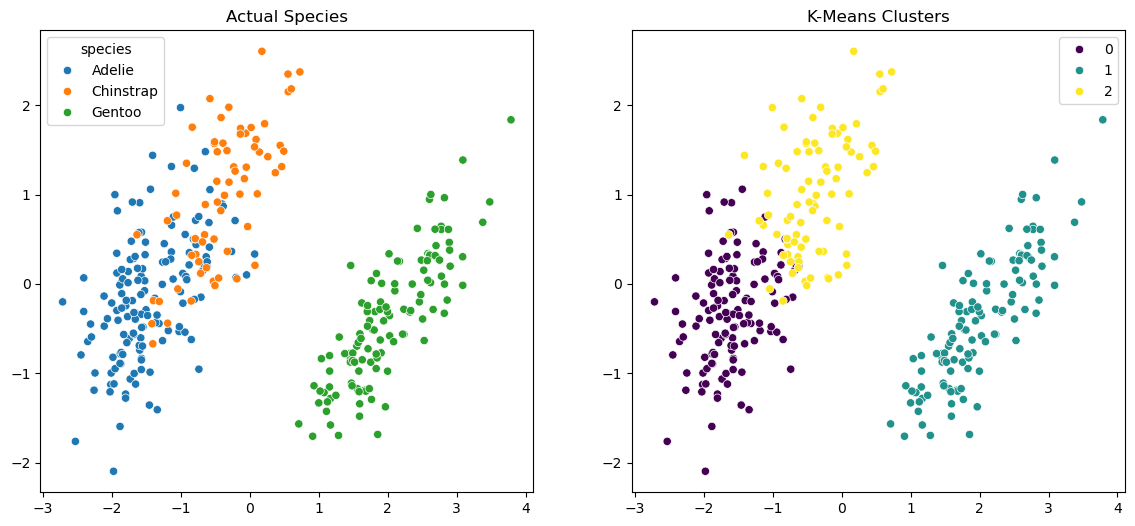

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

penguins = sns.load_dataset("penguins")

penguins_clean = penguins.dropna().copy()

numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_num = penguins_clean[numeric_cols]
y_true = penguins_clean['species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=axes[0])
axes[0].set_title('PCA of Palmer Penguins')
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_true, ax=axes[1])
axes[1].set_title('t-SNE of Palmer Penguins')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan2 = DBSCAN(eps=1.2, min_samples=4)
dbscan_labels2 = dbscan2.fit_predict(X_scaled)

print(f"K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")
if len(set(dbscan_labels)) > 1:
    print(f"DBSCAN 1 Silhouette Score: {silhouette_score(X_scaled, dbscan_labels):.3f}")
if len(set(dbscan_labels2)) > 1:
    print(f"DBSCAN 2 Silhouette Score: {silhouette_score(X_scaled, dbscan_labels2):.3f}")

ari = adjusted_rand_score(y_true, kmeans_labels)
nmi = normalized_mutual_info_score(y_true, kmeans_labels)
print(f"K-Means ARI: {ari:.3f} | NMI: {nmi:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, ax=axes[0])
axes[0].set_title('Actual Species')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', ax=axes[1])
axes[1].set_title('K-Means Clusters')
plt.show()

Unsupervised methods (specifically K-Means) recover the species structure remarkably well. Adelie and Chinstrap penguins have some overlap in their physical dimensions, which causes slight confusion in the clusters. Gentoo penguins clustered almost perfectly by all the models because of their distinct physical specifications. DBSCAN struggles slightly more because adelie and chinstrap penguins partially converge in clusters because of their pyshical lookalikeness.

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

X = penguins_clean.drop(columns=['species'])
y = penguins_clean['species']

numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)
    print(f"--- {name} ---")
    print(f"Accuracy: {scores['test_accuracy'].mean():.3f}")
    print(f"F1 (Macro): {scores['test_f1_macro'].mean():.3f}\n")

pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), 
                              ('classifier', RandomForestClassifier(random_state=42))])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline_rf, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X, y)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

--- Logistic Regression ---
Accuracy: 0.994
F1 (Macro): 0.992

--- Random Forest ---
Accuracy: 0.991
F1 (Macro): 0.989

--- SVC ---
Accuracy: 0.994
F1 (Macro): 0.992

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV F1 Score: 0.989


              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



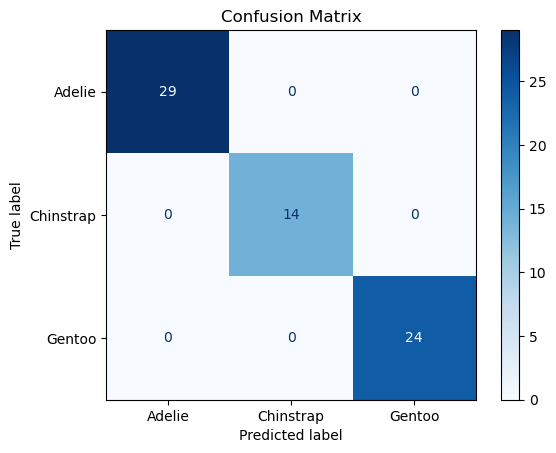

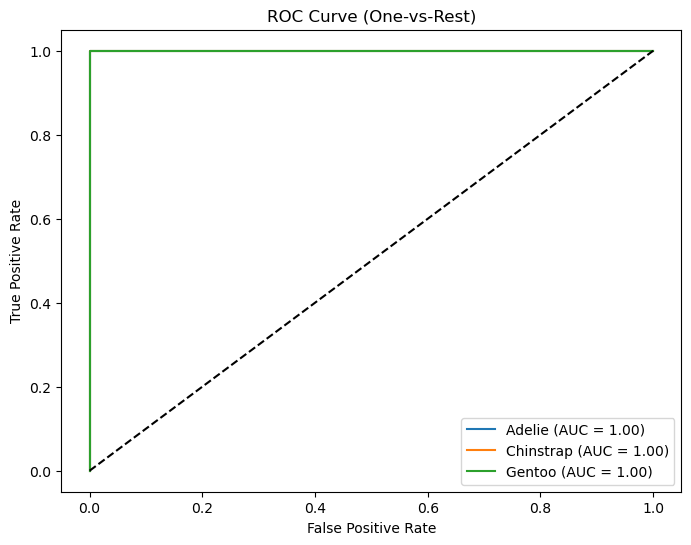

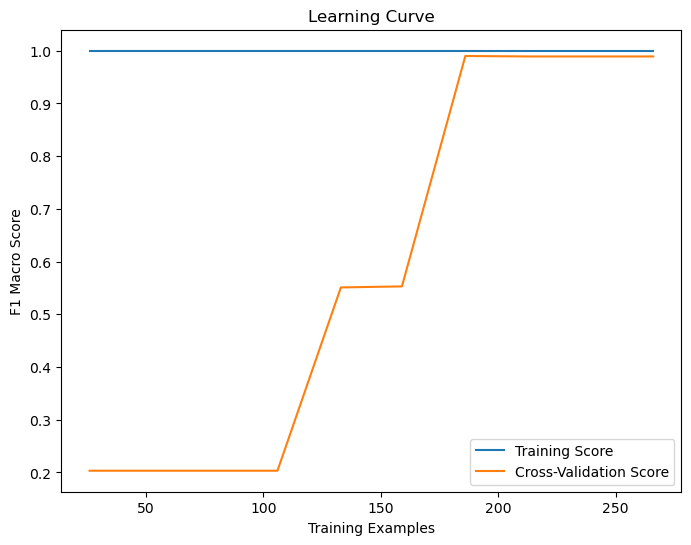

C:\Users\user\AppData\Local\Temp\ipykernel_21660\1964134993.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


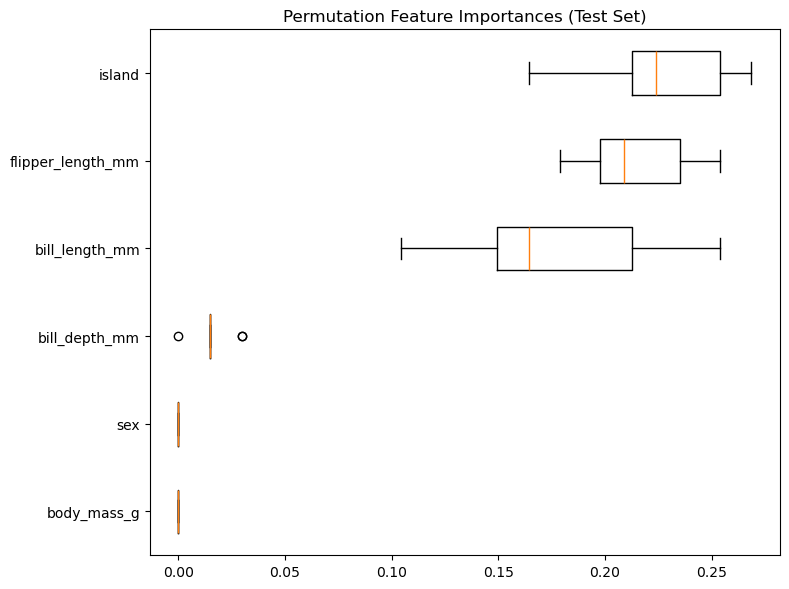

In [3]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=best_model.classes_)
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(best_model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=cv, scoring='f1_macro', train_sizes=np.linspace(0.1, 1.0, 10))

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Validation Score')
plt.xlabel('Training Examples')
plt.ylabel('F1 Macro Score')
plt.title('Learning Curve')
plt.legend()
plt.show()

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(8, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Feature Importances (Test Set)")
plt.tight_layout()
plt.show()

over and underfitting: The learning curves show that training and validation scores converge at a very high level.That means model is not under or overfitted.

Hardest Species to Classify: Chinstrap and Adelie. Their physical appearence look like each other and that leads to little confusion in models. In the other hand, Gentoo is very different from other 2 species pyhsically, that is why model distinguish them perfectly.

Driving Features: Permutation importance reveals that bill_length_mm and flipper_length_mm are consistently the strongest predictors for distinguishing species.

Data Leakage/Issues: No signs of data leakage. Because the dataset is small, high scores are standard for this dataset, not necessarily meaning of data leakage.

In [4]:
import joblib

joblib.dump(best_model, 'penguin_model.pkl')

['penguin_model.pkl']

In [5]:
import requests

url = "http://127.0.0.1:5000/predict"

# 1. Valid Request
valid_data = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}
response = requests.post(url, json=valid_data)
print("Valid Response:", response.json())

# 2. Invalid Request (Missing 'sex' and 'island')
invalid_data = {
    "bill_length_mm": 39.1,
    "body_mass_g": 3750.0
}
response_invalid = requests.post(url, json=invalid_data)
print("Invalid Response:", response_invalid.json())

Valid Response: {'predicted_species': 'Adelie', 'probabilities': {'Adelie': 1.0, 'Chinstrap': 0.0, 'Gentoo': 0.0}}
Invalid Response: {'error': "Missing features. Required: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"}


Penguin Prediction API
Endpoint: POST /predict
Description: Returns the predicted penguin species and class probabilities based on physical traits.

Expected Input Format (JSON):

JSON
{
  "bill_length_mm": float,
  "bill_depth_mm": float,
  "flipper_length_mm": float,
  "body_mass_g": float,
  "island": string ("Torgersen", "Biscoe", "Dream"),
  "sex": string ("Male", "Female")
}
Example Response (Success 200 OK):

JSON
{
  "predicted_species": "Adelie",
  "probabilities": {
    "Adelie": 0.85,
    "Chinstrap": 0.10,
    "Gentoo": 0.05
  }
}